In [2]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
import os
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

Welcome to JupyROOT 6.26/16


In [1]:
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2499.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/multihit_detector_sim_lossy_2499.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002400/MicroProdN4p1_NDComplex_FHC.spill.full.0002499.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

NameError: name 'np' is not defined

In [3]:
dbscan_cluster_list = []
spill_level_hits = []
spills_in_file = np.unique(dbscan_hits[:,-4])
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    spill_level_hits.append(spill_level)
    segments_in_spill = np.unique(spill_level[:,-2])
    for segment_number in segments_in_spill:
        time_segment_level = spill_level[spill_level[:,-2] == segment_number]
        clusters_in_segment = np.unique(time_segment_level[:,-1])
        for cluster_number in clusters_in_segment:
            dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
            rows = []
            for hit in dbscan_cluster_level:
                rows.append(hit)
    
            dbscan_hits_with_info = np.vstack(rows)
            dbscan_cluster_list.append(dbscan_hits_with_info)

11224.75 14376.25
-2629.5251251273958 -47.99425433145693


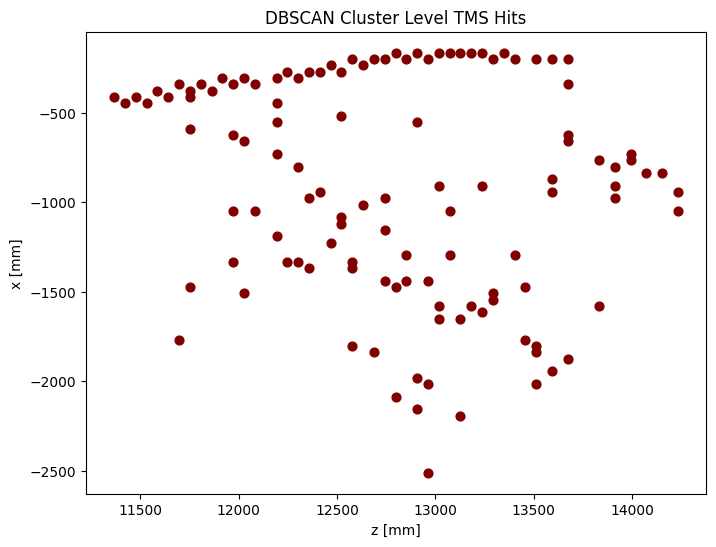

In [4]:
chosen_slice = dbscan_cluster_list[178]

zs = chosen_slice[:,4]
xs = chosen_slice[:,2]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, color='maroon', s =40)
plt.xlabel('z [mm]')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
plt.ylabel('x [mm]')
plt.title('DBSCAN Cluster Level TMS Hits')
plt.savefig('dbscan_level.png')
print(xmin,xmax)
print(ymin,ymax)

In [6]:
np.unique(chosen_slice[:,0])

array([3548., 3550.])

In [7]:
spill_7 = spill_level_hits[7]
max(spill_7[:,5]) - min(spill_7[:,5])

np.float64(21538.2820186615)

In [8]:
time_segement_hits = spill_7[spill_7[:,-2] == 60]
max(time_segement_hits[:,5]) - min(time_segement_hits[:,5])

np.float64(209.82039546966553)

In [9]:
len(np.unique(spill_7[:,-2]))

101

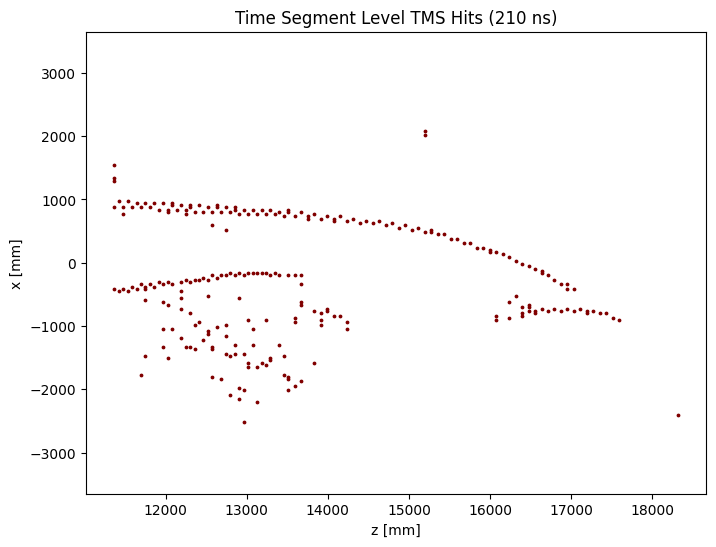

In [10]:
zs = time_segement_hits[:,4]
xs = time_segement_hits[:,2]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, s =3, c = 'maroon')
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.ylim((-3650,3650))
plt.title('Time Segment Level TMS Hits (210 ns)')
plt.savefig('time_segment_level.png')

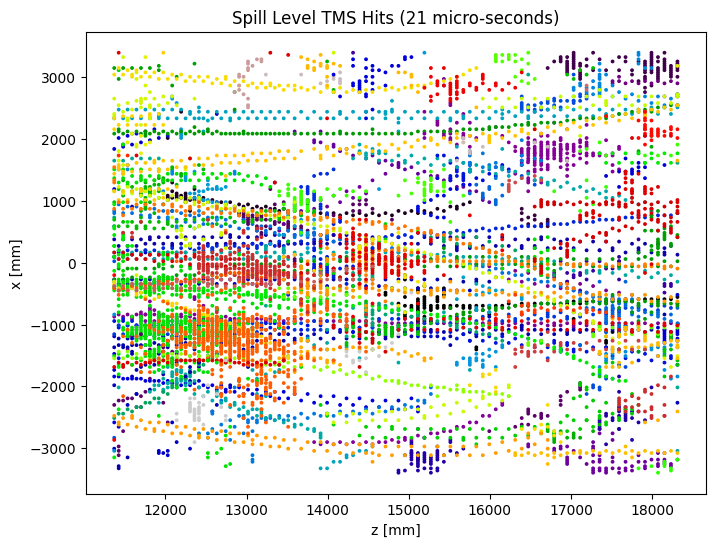

In [11]:
zs = spill_7[:,4]
xs = spill_7[:,2]
nns = spill_7[:,0]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, s = 3, c = nns, cmap = 'nipy_spectral' )
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Spill Level TMS Hits (21 micro-seconds)')
plt.savefig('presentation_plots/colorful_spill_level.png')


(np.float64(11020.5), np.float64(18665.5))
(np.float64(-3736.1161924280314), np.float64(3736.1161924280314))


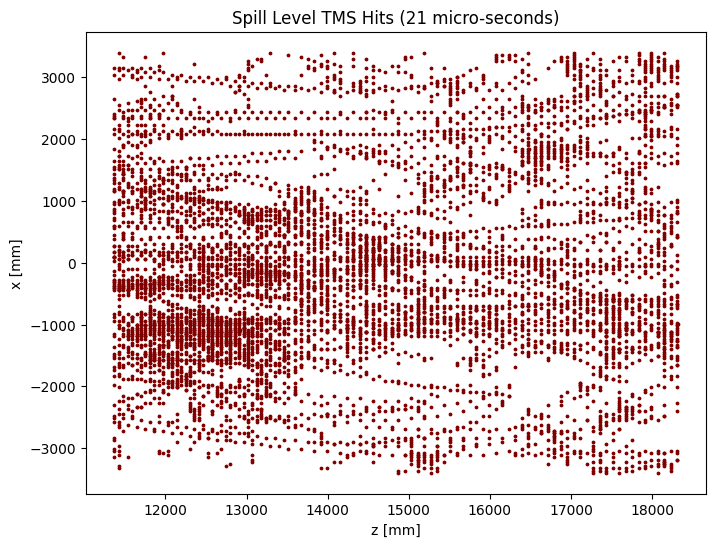

In [15]:
zs = spill_7[:,4]
xs = spill_7[:,2]
nns = spill_7[:,0]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, s = 3, c = 'maroon')
big_xmin, big_xmax = plt.xlim()
big_ymin, big_ymax = plt.ylim()
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Spill Level TMS Hits (21 micro-seconds)')
plt.savefig('presentation_plots/maroon_spill_level.png')
print((big_xmin,big_xmax))
print((big_ymin,big_ymax))

In [12]:
#gotta go back and find the detector effect sim lmao. 
effects_hits = merged_hits_array[merged_hits_array[:,0] == 3550]

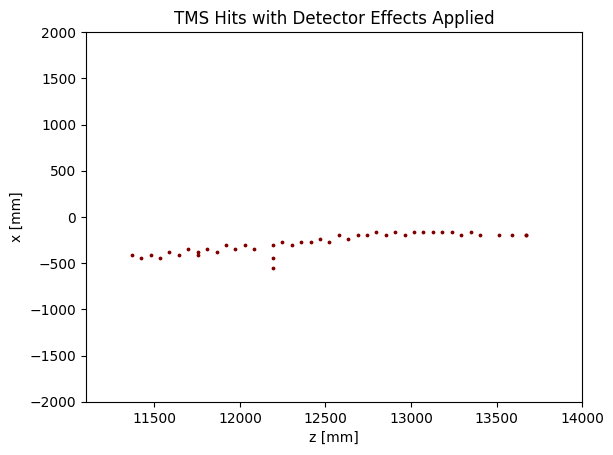

In [13]:
zs = effects_hits[:,4]
xs = effects_hits[:,2]
PEs = effects_hits[:,6]
plt.scatter(zs, xs, s =3, c = 'maroon')
plt.title('TMS Hits with Detector Effects Applied')
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.xlim((11100,14000))
plt.ylim((-2000,2000))
plt.savefig('presentation_plots/detector_effects.png')

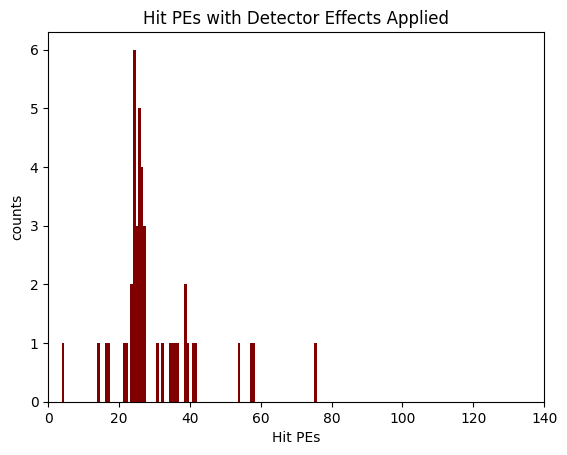

In [14]:
plt.hist(PEs, bins=100, color='maroon')
plt.xlim(0,140)
plt.xlabel('Hit PEs')
plt.title('Hit PEs with Detector Effects Applied')
plt.ylabel('counts')
plt.savefig('effects_PEs.png')

In [15]:
#hes back
class TMS_hit_simple:
    def __init__(self, tms_hit_seg, neutrino_number, hit_number):
        self.tms_hit_seg = tms_hit_seg
        self.neutrino_number = neutrino_number #associated with what neutrino vertex
        self.hit_number = hit_number #which TMS hit in the event
        self.x_diff = 0.
        self.y_diff = 0.
        self.z_diff = 0.
        self.Dx = 0.
        
    #Defining attributes based on the tms_hit_seg, avg position in each dimension plus time and energy deposition
    def GetNeutrinoNumber(self):
        return(self.neutrino_number)
        
    def GetHitNumber(self):
        return(self.hit_number)
        
    def GetHitX(self):
        x_pos = (self.tms_hit_seg.GetStart()[0] + self.tms_hit_seg.GetStop()[0]) / 2 
        return(x_pos)
        
    def GetHitY(self):
        y_pos = (self.tms_hit_seg.GetStart()[1] + self.tms_hit_seg.GetStop()[1]) / 2
        return(y_pos)
        
    def GetHitZ(self):
        z_pos = (self.tms_hit_seg.GetStart()[2] + self.tms_hit_seg.GetStop()[2]) / 2
        return(z_pos)
        
    def GetHitT(self):
        time = (self.tms_hit_seg.GetStart()[3] + self.tms_hit_seg.GetStop()[3]) / 2
        return(time)
        
    def GetDx(self):
        self.x_diff = (self.tms_hit_seg.GetStart()[0] - self.tms_hit_seg.GetStop()[0])
        self.y_diff = (self.tms_hit_seg.GetStart()[1] - self.tms_hit_seg.GetStop()[1])
        self.z_diff = (self.tms_hit_seg.GetStart()[2] - self.tms_hit_seg.GetStop()[2])
        self.Dx = ((self.x_diff)**2 + (self.y_diff)**2 + (self.z_diff)**2)**(1/2)
        return(self.Dx)
        
    def GetPrimaryDeposit(self):
        PrimaryDeposit = self.tms_hit_seg.GetEnergyDeposit()
        return(PrimaryDeposit)    

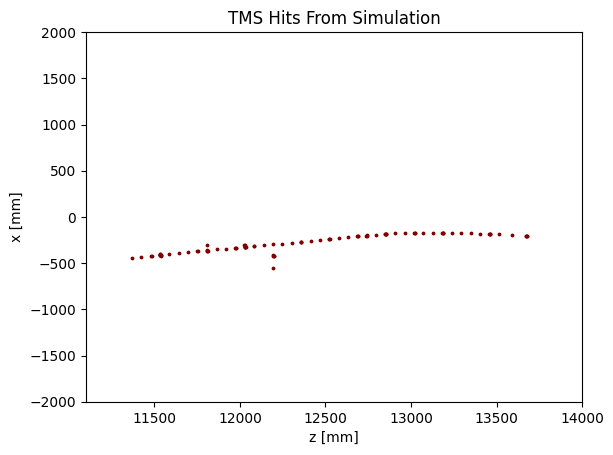

In [16]:
edep_evts = f.Get("EDepSimEvents") 
edep_evt = root.TG4Event()
edep_evts.SetBranchAddress("Event",root.AddressOf(edep_evt))
edep_evts.GetEntry(3550)
hit_segments = edep_evt.SegmentDetectors['volTMS']
xs = []
zs = []
PEs = []
for i in range(hit_segments.size()):
    hit_true = TMS_hit_simple(hit_segments[i], 3550, i)
    xs.append(hit_true.GetHitX())
    zs.append(hit_true.GetHitZ())
    PEs.append(hit_true.GetPrimaryDeposit()*50)

plt.scatter(zs, xs, s =3, c = 'maroon')
plt.title('TMS Hits From Simulation')
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.xlim((11100,14000))
plt.ylim((-2000,2000))
plt.savefig('presentation_plots/raw_sim.png')

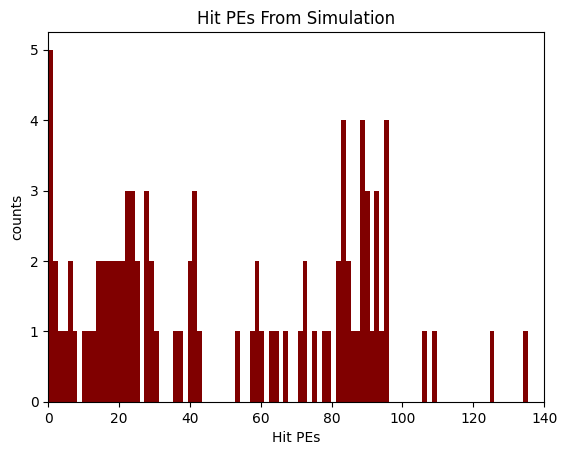

In [17]:
plt.hist(PEs, bins=100, color = 'maroon')
plt.xlim(0,140)
plt.xlabel('Hit PEs')
plt.title('Hit PEs From Simulation')
plt.ylabel('counts')
plt.savefig('presentation_plots/sim_PEs.png')

In [18]:
chosen_node_positions = chosen_slice[:,[0,1]]

In [19]:
torch_dataset = torch.load('/sdf/data/neutrino/summer25/ktwall/processed/file_2553_graphs.pt')

/lscratch/ktwall/tmp/ipykernel_327265/3231503173.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch_dataset = torch.load('/sdf/data/neutrino/summer25/ktwall/processed

In [20]:
graph_numbers = []
for data in torch_dataset:
    graph_numbers.append(data.graph_number)

In [21]:
graph_numbers.index(1789)

1487

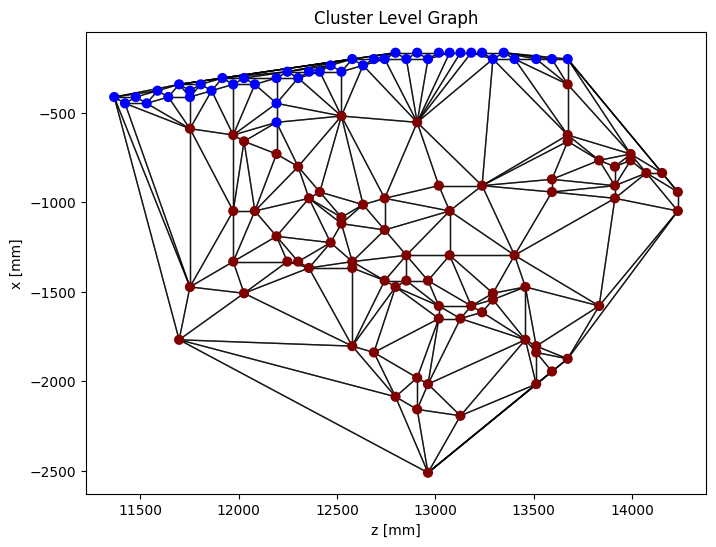

In [23]:
torch_dataset[1487]
cluster_n = 1487
zs = (torch_dataset[cluster_n].x)[:,0]
xs = (torch_dataset[cluster_n].x)[:,1]
nodes = (torch_dataset[cluster_n].x)[:,[0,1]]
labels = (torch_dataset[cluster_n].y)

colors = []
for label in labels:
    if label == 0:
        colors.append('blue')
    else:
        colors.append('maroon')
        
edges_z = zs[torch_dataset[cluster_n].edge_index]
edges_x = xs[torch_dataset[cluster_n].edge_index]
plt.figure(figsize=(8, 6))
plt.plot(edges_z.numpy(), edges_x.numpy(), 'k-', lw=1, alpha=0.7)
plt.xlim((xmin,xmax))
plt.ylim((ymin,ymax))
plt.scatter(zs, xs, c= colors , s=40, zorder=3)
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Cluster Level Graph')
plt.savefig('labeled_graph.png')

In [24]:
spill_7

array([[3204.        , 1604.        , -695.90843846, ...,    8.        ,
           0.        ,    0.        ],
       [3204.        , 1607.        , -695.90843846, ...,    8.        ,
           0.        ,    0.        ],
       [3204.        ,   63.        , -695.90843846, ...,    8.        ,
           0.        ,    0.        ],
       ...,
       [3578.        ,  695.        ,   59.22219228, ...,    8.        ,
          98.        ,    0.        ],
       [3581.        ,  217.        , 1120.36593591, ...,    8.        ,
          99.        ,    0.        ],
       [3621.        ,  122.        , 2901.26885215, ...,    8.        ,
         100.        ,    0.        ]])

In [55]:
def MakeKDSegments(hits, bandwidth = 15, mesh_points = 1000, plot = False):
    
    hit_ts = hits[:,5] #extract just the time series data. 
    
    hit_ts_reshaped = hit_ts.reshape(-1, 1)

    # KDE fitting using a gaussian kernel. 
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(hit_ts_reshaped)

    # Evaluate KDE on a fine grid - project our function onto a fine grid to look for local minima
    #This is a necessary step to be able to find our local minima numerically. Basically the kde gives us our functional form, we need to plot it on points to get out the pdf. 
    #The plotting with the points is accomplished by pulling the score_samples method, which returns log likelihoods. We then convert these into actually probabilitiy densities. 
    t_plot = np.linspace(hit_ts.min() - 2, hit_ts.max() + 2, mesh_points).reshape(-1, 1) 
    log_dens = kde.score_samples(t_plot)
    dens = np.exp(log_dens)

    # Find valleys in KDE curve (ie, local minima)
    #Can use scipy peak finding, but invert data so we are really finding the local minima! Returns indices
    inverted = -dens
    valleys, _ = find_peaks(inverted)
    valley_positions = t_plot[valleys].flatten() #this step maps our indices onto actual times. 

    # Assign cluster index based on which region the point falls into
    def assign_cluster(t, boundaries):
        for i, b in enumerate(boundaries): #will loop through boundaries and the last one assigned will be the one it fits into.
            if t < b:
                return(i)
        return(len(boundaries))

    labels = np.array([assign_cluster(t, valley_positions) for t in hit_ts]) #assign labels to our hits. 

    
    if (plot == True): #output a KDE plot
        plt.figure(figsize=(8, 6))
        plt.plot(t_plot[:, 0], dens, label="KDE")
        plt.scatter(hit_ts, np.zeros_like(hit_ts), c=labels, cmap='tab20', s=50, label="Labeled Time Segments")
        for v in valley_positions:
            plt.axvline(v, color='gray', linestyle='--', linewidth=1)
        plt.title("KDE-based hit Segmentation")
        plt.xlabel("Hit Time")
        xmin, xmax = plt.xlim()
        print((xmin,xmax))
        plt.yticks([])
        plt.legend()
        plt.savefig('presentation_plots/KDE_simple.png')

    print(f"We found {len(np.unique(labels))} clusters")
    clusters_added = np.column_stack((hits, labels)) #save our data with cluster labels added to the end of each hit row. 
    return(clusters_added)

(np.float64(8400000006.664634), np.float64(8400000693.08854))
We found 8 clusters


array([[ 3.20400000e+03,  1.60400000e+03, -6.95908438e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.20400000e+03,  1.60700000e+03, -6.95908438e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.20400000e+03,  6.30000000e+01, -6.95908438e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 3.23400000e+03,  1.85000000e+02, -8.02022813e+02, ...,
         3.00000000e+00,  1.00000000e+00,  7.00000000e+00],
       [ 3.23400000e+03,  5.50000000e+01, -9.43508645e+02, ...,
         3.00000000e+00,  1.00000000e+00,  7.00000000e+00],
       [ 3.23400000e+03,  5.60000000e+01, -9.43508645e+02, ...,
         3.00000000e+00,  1.00000000e+00,  7.00000000e+00]])

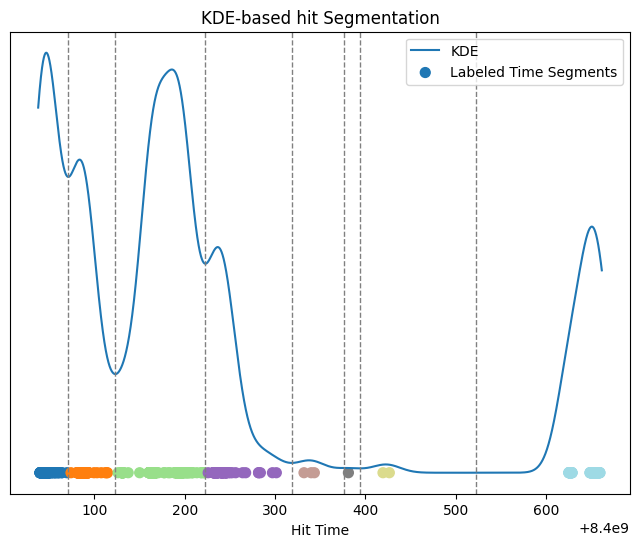

In [56]:
MakeKDSegments(spill_7[:500,:], bandwidth = 15, mesh_points = 10000, plot = True)

In [ ]:
#need to quickly run interence w/ arthur. 